<a href="https://colab.research.google.com/github/deepanshiagarwal580/Seasonal-Agriculture-performance-analysis/blob/main/majorproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/MAJOR PROJECT DATASET.csv")

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
df.shape


(4000, 28)

In [ ]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [ ]:
df.nunique()

,0
Farm_ID,4000
State,8
District,10
Crop,8
Season,3
Farm_Area_Hectares,1370
Rainfall_mm,3256
Avg_Temperature_C,204
Humidity_pct,573
Sunlight_Hours_Day,71


In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(
    df['Rainfall_mm'].median()
)

df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(
    df['Soil_Moisture_pct'].median()
)

df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(
    df['Yield_Tonnes_Ha'].median()
)

In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(4000, 28)

In [ ]:
df['Season'].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


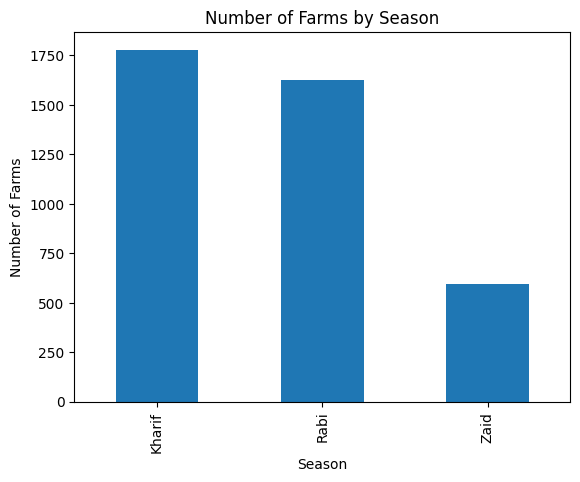

In [ ]:
df['Season'].value_counts().plot(kind='bar')

plt.title('Number of Farms by Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')
plt.show()

## Analytical Questions

1. How does agricultural yield vary across different seasons?

2. How does agricultural production differ across seasons?

3. How do revenue, cost and profit vary across seasons?

4. How do environmental conditions differ across seasons?

5. How does agricultural resource usage vary across seasons?

6. How does water efficiency vary across seasons and irrigation methods?

7. Are seasonal yield patterns consistent across different crops?

8. What relationships exist between environmental/resource factors and agricultural performance?

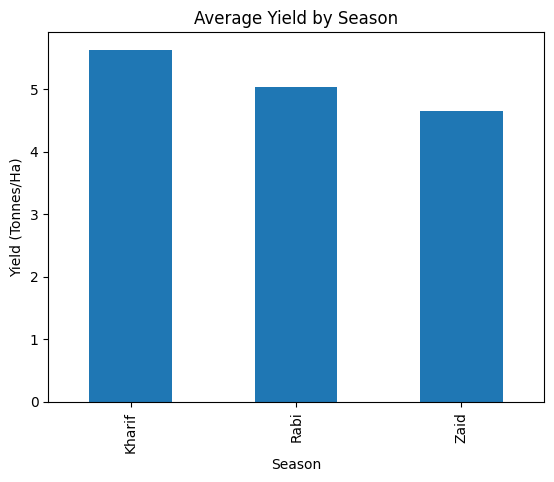

In [ ]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean()
season_yield

season_yield.plot(kind='bar')
plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

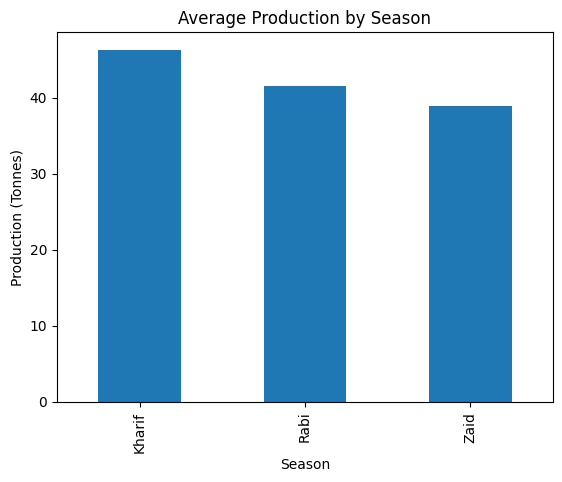

In [ ]:
df.groupby('Season')['Production_Tonnes'].mean()

df.groupby('Season')['Production_Tonnes'].mean().plot(kind='bar')
plt.title('Average Production by Season')
plt.ylabel('Production (Tonnes)')
plt.show()

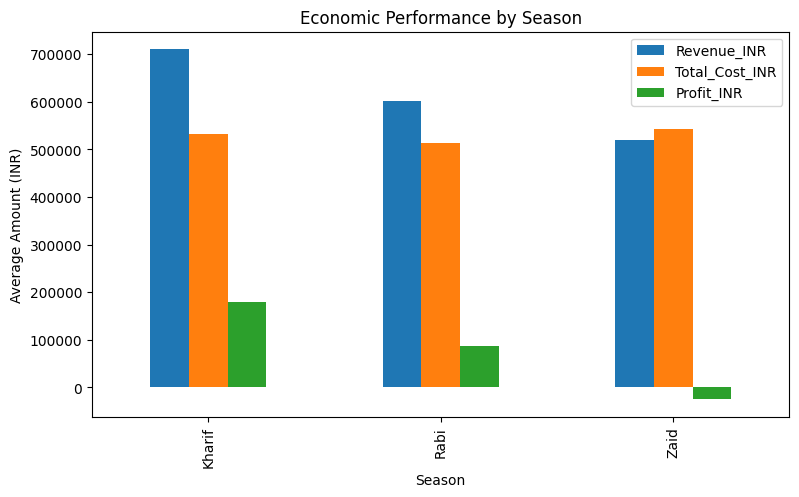

In [ ]:
df.groupby('Season')[[
    'Revenue_INR',
    'Total_Cost_INR',
    'Profit_INR'
]].mean()


df.groupby('Season')[
    ['Revenue_INR', 'Total_Cost_INR', 'Profit_INR']
].mean().plot(kind='bar', figsize=(9,5))

plt.title('Economic Performance by Season')
plt.ylabel('Average Amount (INR)')
plt.show()

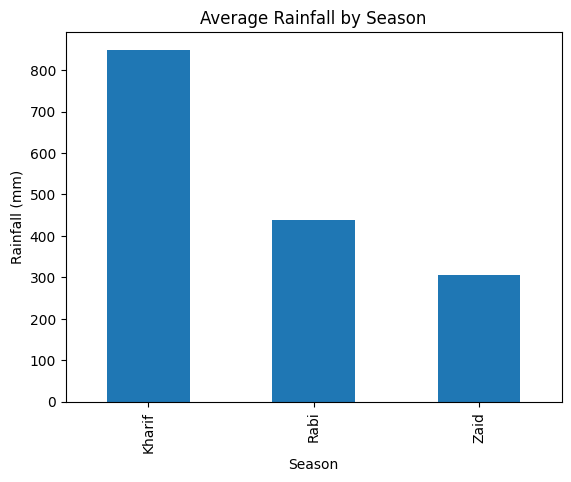

In [ ]:
df.groupby('Season')[[
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct'
]].mean()


df.groupby('Season')['Rainfall_mm'].mean().plot(kind='bar')
plt.title('Average Rainfall by Season')
plt.ylabel('Rainfall (mm)')
plt.show()

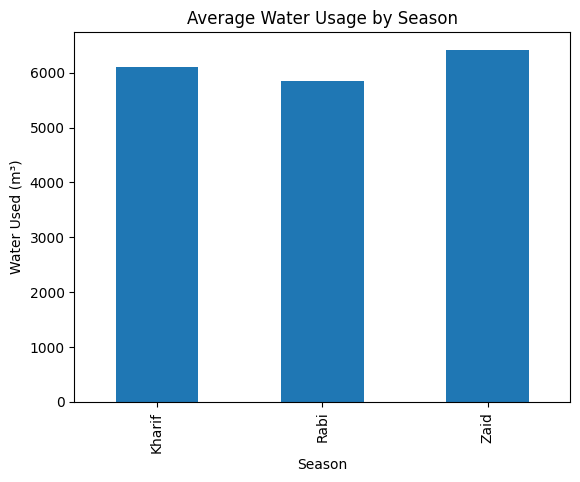

In [ ]:
 df.groupby('Season')[[
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Water_Used_m3'
]].mean()


df.groupby('Season')['Water_Used_m3'].mean().plot(kind='bar')
plt.title('Average Water Usage by Season')
plt.ylabel('Water Used (m³)')
plt.show()

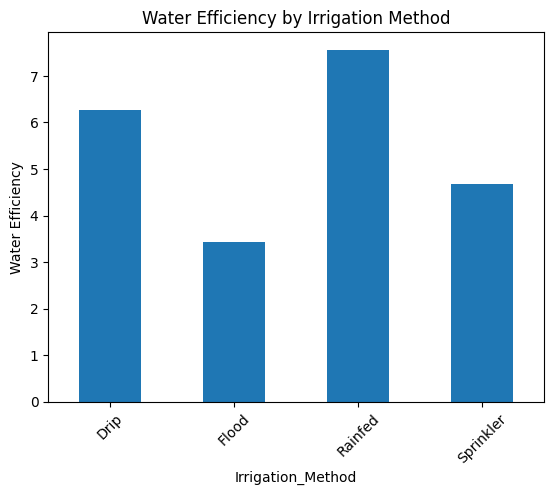

In [ ]:
df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean()



df.groupby('Irrigation_Method')[
    'Water_Efficiency_t_per_1000m3'
].mean()



df.groupby('Irrigation_Method')[
    'Water_Efficiency_t_per_1000m3'
].mean().plot(kind='bar')

plt.title('Water Efficiency by Irrigation Method')
plt.ylabel('Water Efficiency')
plt.xticks(rotation=45)
plt.show()

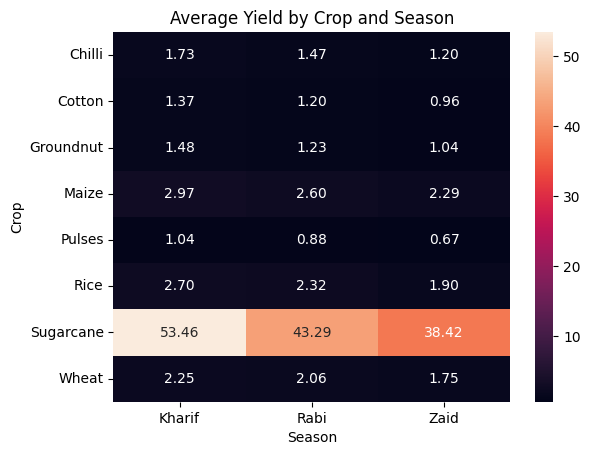

In [ ]:
crop_season_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

crop_season_yield


sns.heatmap(crop_season_yield, annot=True, fmt='.2f')

plt.title('Average Yield by Crop and Season')
plt.show()

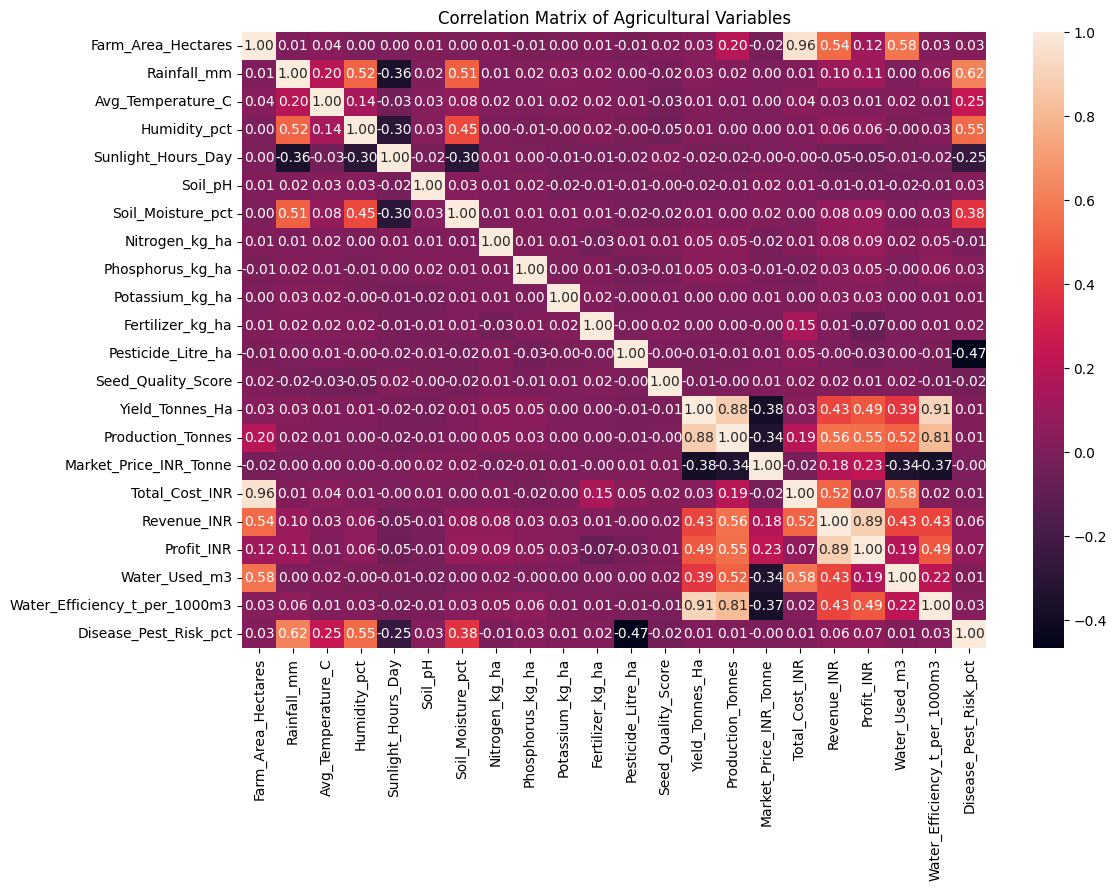

In [ ]:
correlation_matrix = df.select_dtypes(
    include=np.number
).corr()

correlation_matrix


plt.figure(figsize=(12,8))

sns.heatmap(correlation_matrix, annot=True, fmt='.2f')

plt.title('Correlation Matrix of Agricultural Variables')
plt.show()

# ALL 8 QUESTIONS ANSWERED

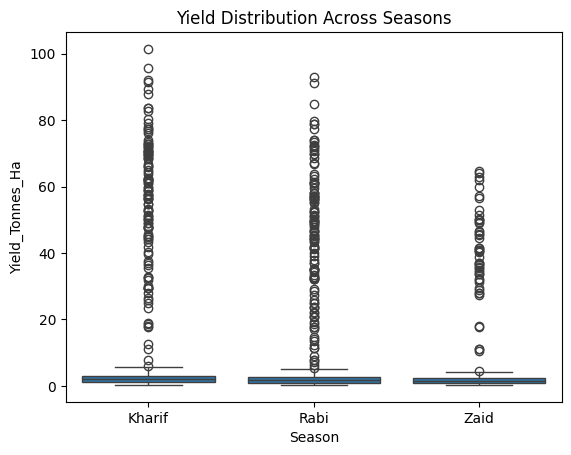

In [ ]:
#UNUSUAL FINDINGS
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha')
plt.title('Yield Distribution Across Seasons')
plt.show()

## Overall Findings

1. Agricultural yield differs across seasons, with Kharif showing the highest average yield, followed by Rabi and Zaid.

2. Agricultural production also varies across seasons, with Kharif recording the highest average production.

3. Economic performance differs considerably across seasons. Kharif has the highest average profit, while Zaid shows a negative average profit in the dataset.

4. Environmental conditions vary substantially across seasons. Kharif has the highest average rainfall, while Zaid has the highest average temperature.

5. Resource usage shows seasonal differences, particularly in water usage. Zaid has the highest average water usage among the three seasons.

6. Water efficiency differs across irrigation methods. In the dataset, Rainfed farming has the highest average water efficiency, while Drip irrigation shows the highest average yield.

7. Crop performance is not identical across seasons. The crop-season comparison shows that yield generally differs between Kharif, Rabi and Zaid for individual crops.

8. Correlation analysis shows strong relationships between yield and water efficiency, production and profit. These relationships indicate associations within the dataset and do not by themselves establish causation.


## Conclusion

The analysis of the agricultural dataset shows that agricultural
performance varies across Kharif, Rabi and Zaid seasons.

Differences were observed in crop yield, production, economic
performance, environmental conditions, resource usage and water
efficiency.

Kharif showed the strongest overall performance in terms of average
yield, production and profit in the analyzed dataset, while Zaid
showed comparatively lower yield and negative average profit.

The crop-season and correlation analyses further helped identify
patterns and relationships among agricultural variables.

Overall, the analysis demonstrates how data analytics and
visualization can be used to understand seasonal agricultural
performance and support evidence-based agricultural planning.

## Recommendations

1. Agricultural planning should consider seasonal differences in
   yield, production and environmental conditions.

2. Resource usage, especially water usage, should be monitored
   carefully across different seasons.

3. Irrigation methods should be evaluated not only on yield but
   also on water efficiency.

4. Crop selection and seasonal planning can consider the observed
   crop-wise and season-wise performance patterns.

5. Farmers and agricultural planners can use data-driven insights
   to improve seasonal resource and production planning.

6. Future analysis can incorporate historical, real-time weather
   and market data to improve agricultural decision-making.
   